In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

import load_mnist

In [2]:
# load data using functions coded in load_mnist.py
y_train = load_mnist.load_labels(load_mnist.f_training_labels)
X_train = np.hstack((load_mnist.load_images(load_mnist.f_training_images), np.ones((len(y_train),1))))/255.0

y_test = load_mnist.load_labels(load_mnist.f_test_labels)
X_test = np.hstack((load_mnist.load_images(load_mnist.f_test_images), np.ones((len(y_test),1))))/255.0

# Initial MLPClassifier test

In [5]:
for i in range(10):
    clf = MLPClassifier(solver='sgd', alpha=1e-5, hidden_layer_sizes=(60,), random_state=1, learning_rate_init=0.1)
    clf.fit(X_train, y_train.flatten())
    print('Error rate {:0.1%}'.format(1-clf.score(X_test, y_test.flatten())))

Error rate 2.3%
Error rate 2.3%
Error rate 2.3%
Error rate 2.3%
Error rate 2.3%
Error rate 2.3%
Error rate 2.3%
Error rate 2.3%
Error rate 2.3%
Error rate 2.3%


# Effect of neuron count, and number of hidden layers

In [9]:
neuron_arr = np.array([30,60,90,120])
layer_arr = np.arange(1,4)

test_error = np.zeros((len(neuron_arr),len(layer_arr)))

for j, layers in enumerate(layer_arr):

    for i, neurons in enumerate(neuron_arr):
        
        hidden_layers = [neurons]*layers
        
        clf = MLPClassifier(solver='sgd', alpha=1e-5, hidden_layer_sizes=hidden_layers, random_state=1, learning_rate_init=0.1)
        clf.fit(X_train, y_train.flatten())
        
        err = 1-clf.score(X_test, y_test.flatten())
        
        test_error[i,j] = err
        print('Error rate {:0.1%}'.format(err))

Error rate 3.5%
Error rate 2.3%
Error rate 1.9%
Error rate 2.0%
Error rate 3.6%
Error rate 2.5%
Error rate 1.8%
Error rate 1.8%
Error rate 3.4%
Error rate 2.3%
Error rate 2.2%
Error rate 1.8%


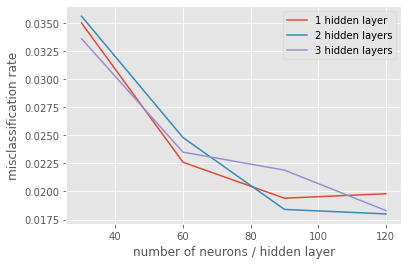

In [11]:
plt.plot(neuron_arr, test_error[:,0], label='1 hidden layer')
plt.plot(neuron_arr, test_error[:,1], label='2 hidden layers')
plt.plot(neuron_arr, test_error[:,2], label='3 hidden layers')

plt.xlabel('number of neurons / hidden layer')
plt.ylabel('misclassification rate')

plt.legend()

# Refined look at neuron count, with 2 hidden layers

In [12]:
neuron_arr = np.arange(40, 210, 20)

test_error = np.zeros(len(neuron_arr))

for i, neurons in enumerate(neuron_arr):
        
    hidden_layers = [neurons]*2
        
    clf = MLPClassifier(solver='sgd', alpha=1e-5, hidden_layer_sizes=hidden_layers, random_state=1, learning_rate_init=0.1)
    clf.fit(X_train, y_train.flatten())
        
    err = 1-clf.score(X_test, y_test.flatten())
        
    test_error[i] = err
    print('Error rate {:0.1%}'.format(err))

Error rate 3.0%
Error rate 2.5%
Error rate 2.4%
Error rate 1.7%
Error rate 1.8%
Error rate 1.8%
Error rate 1.6%
Error rate 1.6%
Error rate 1.7%


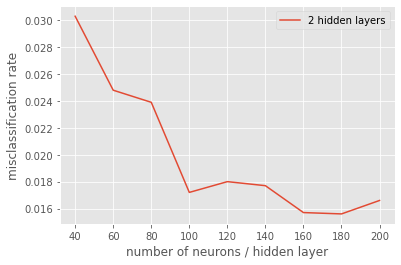

In [14]:
plt.plot(neuron_arr, test_error, label='2 hidden layers')

plt.xlabel('number of neurons / hidden layer')
plt.ylabel('misclassification rate')

plt.legend()

# Explore bias of classifier

In [20]:
clf = MLPClassifier(solver='sgd', alpha=1e-5, hidden_layer_sizes=(160,160), random_state=1, learning_rate_init=0.1)
clf.fit(X_train, y_train.flatten())

err = 1-clf.score(X_test, y_test.flatten())
print('Error rate {:0.1%}'.format(err))

Error rate 1.6%


In [26]:
# test using test dataset
y_hat = clf.predict(X_test)

error_rate = 1-np.sum(np.equal(y_hat.flatten(), y_test.flatten())) / len(y_test)

import pandas as pd

df = pd.DataFrame(data=np.hstack((y_test, np.equal(y_hat.reshape((len(y_test),1)),y_test))), columns=['digit', 'correct'])
pt = df.pivot_table(index='digit', values=['correct', 'correct'], aggfunc=[len, np.sum])
pt = pt.stack().reset_index()
pt['error'] = 1-pt['sum']/pt['len']

In [27]:
pt

,digit,level_1,len,sum,error
0,0.0,correct,980.0,971.0,0.009184
1,1.0,correct,1135.0,1126.0,0.007930
2,2.0,correct,1032.0,1015.0,0.016473
3,3.0,correct,1010.0,995.0,0.014851
4,4.0,correct,982.0,963.0,0.019348
5,5.0,correct,892.0,874.0,0.020179
6,6.0,correct,958.0,940.0,0.018789
7,7.0,correct,1028.0,1014.0,0.013619
8,8.0,correct,974.0,956.0,0.018480
9,9.0,correct,1009.0,989.0,0.019822


Text(0, 0.5, 'misclassification rate')

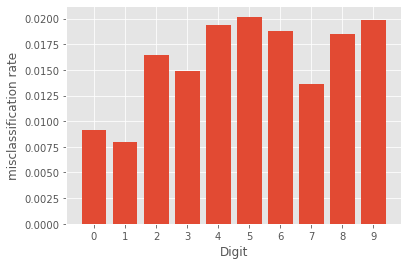

In [30]:
plt.bar(pt['digit'], pt['error'])
plt.xticks(range(10))
plt.xlabel('Digit')
plt.ylabel('misclassification rate')